<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_1_1_MLR_Ames_Part1_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames Iowa: Part 1,  Data Cleaning

Author: Brad Sheese
___

## Purpose of this Notebook
This notebook demonstrates manual cleaning of a real-world dataset. The intent of the cleaning is to prepare the dataset for inference, wherein we are interested in examining individual coefficients of features in the model.

### Data Cleaning, Under and Over Cleaning
The primary goal of data cleaning is to transform messy, raw data into a structured, model-ready format that maximizes true predictive signals and minimizes disruptive noise. This involves transforming the data in different ways. The trick is that we need to do this  without distorting the underlying reality of the information.

Achieving this balance requires navigating the dual pitfalls of under-cleaning and over-cleaning. Under-cleaning leaves too much chaos in the dataset, such as unhandled missing values, unencoded strings, extreme outliers, or highly collinear features, which can cause machine learning algorithms to crash, fail to converge, or overfit on structural errors. Conversely, over-cleaning stems from an overzealous attempt to simplify or shrink the data, resulting in the destruction of valuable information through the aggressive dropping of features, the clumsy grouping of highly distinct categories into generic buckets, or inappropriate binarization of continuous variables. You always need to balance these two when considering just how much of your data to clean.

## Data for this Exercise
**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

The Ames housing dataset, compiled by Dean De Cock in 2011, is a comprehensive collection of information detailing nearly every aspect of residential property sales in Ames, Iowa, from 2006 to 2010. It consists of approximately 2,930 observations and 79 explanatory variables, ranging from house quality and neighborhood to square footage and number of bathrooms, which are used to predict the final "SalePrice" of each home.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Loading the dataframe
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'
df = pd.read_csv(url, sep='\t')

### We're going to do some preliminary cleaning here to make this notebook
### more approachable for beginners.

# Drop as recommended by the author of the dataset (unusual sales)
df = df[df["Gr Liv Area"] < 4000]

# Drop Identifiers. These are unique identifiers
df = df.drop(['Order', 'PID'], axis=1)

# Drop near-constant or highly sparse features to keep the dataset manageable for beginners
sparse_drops = ['Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val', 'Alley', 'Fence']
constant_drops = ['Street', 'Utilities', 'Condition 2', 'Roof Matl', 'Heating', 'Low Qual Fin SF', '3Ssn Porch']

# We will also drop 'Garage Yr Blt' to simplify and avoid leakage
df = df.drop(sparse_drops + constant_drops + ['Garage Yr Blt'], axis=1, errors='ignore')

# Correct Data Types
# MSSubClass is a numeric code, not a magnitude. Convert to string so it's not treated as a continuous number.
df['MS SubClass'] = df['MS SubClass'].astype(str)

df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Lot Shape,Land Contour,Lot Config,Land Slope,Neighborhood,Condition 1,...,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,Screen Porch,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,IR1,Lvl,Corner,Gtl,NAmes,Norm,...,P,210,62,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Reg,Lvl,Inside,Gtl,NAmes,Feedr,...,Y,140,0,0,120,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,IR1,Lvl,Corner,Gtl,NAmes,Norm,...,Y,393,36,0,0,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Reg,Lvl,Corner,Gtl,NAmes,Norm,...,Y,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,IR1,Lvl,Inside,Gtl,Gilbert,Norm,...,Y,212,34,0,0,3,2010,WD,Normal,189900


# Part 1: Pre-Split Cleaning and Exploration

The steps in this section — dropping columns, fixing data types, filling in meaningful NAs, checking for coding errors, and applying log transforms — are all **deterministic**: they apply a fixed formula and compute nothing from the data. Because of this, they can safely be applied to the full dataset before the train/test split. We will see exactly why this distinction matters when we reach the split below.

---

## Missing Values

This is about observations where some variables are absent (NA, blank, null, etc.). Regression usually cannot use rows with missing predictor or outcome values unless you explicitly handle them. Missingness can also bias inference if it is systematic.

## Typical checks:
* How many values are missing?
* Which variables are affected?
* Is missingness random or patterned?

## Common remediation approaches:
1. Listwise deletion: Drop rows with missing values.
    * Good when: missingness is small, approximately random, sample size is large.
    * Risk: loss of power, potential bias.
2. Imputation: Fill in plausible values.
    * Examples: mean/median imputation, regression imputation, multiple imputation (preferred for inference).
    * For inference, multiple imputation is often favored because it preserves uncertainty better.

In [ ]:
# Missing Part 1: Not Actually Missing
# In the Ames dataset, sometimes a missing value is used to indicate a
# housing feature is not present. This is not really missing data. Here we
# replace the missing values with 'None'. Note: These steps are deterministic
# (they don't rely on dataset statistics) and can safely be done on the whole
# dataset before splitting without concerns of data leakage.

# Resolve "Meaningful" NAs
# Basement NAs mean "No Basement"
bsmt_cols = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
for col in bsmt_cols:
    df[col] = df[col].fillna('None')

# Garage NAs mean "No Garage"
garage_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']
for col in garage_cols:
    df[col] = df[col].fillna('None')

# Fireplace NAs mean "No Fireplace"
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')


# Missing Part 2: Looking at Actually Missing

# Produces a Series where the index is the column names and values
# are the total count of missing values
missing_values = df.isnull().sum()

# Columns with missing values
columns_with_missing = missing_values[missing_values > 0]
print(f"Columns with missing values ({len(columns_with_missing)} of {df.shape[1]}):")

if not columns_with_missing.empty:
    for col, count in columns_with_missing.items():
        print(f"  - {col}: {count} missing values, {round(count/df.shape[0] * 100, 1)}% of rows")
else:
    print("  None")

print("\n"+"-"*50+"\n")

print(f'Percent of columns with missing values: {round(len(columns_with_missing)/df.shape[1] * 100)}%')

This particular data set have some missing data. We won't fix this yet. To avoid data leakage between the train and test sets we will wait until after the splits are made to address this.  

## Consistent units/scales

Making sure variables are measured coherently.

### Examples
- Mixing pounds and kilograms
- Annual income mixed with monthly income
- Percentages coded as `0–100` in one place and `0–1` elsewhere

### Why it matters
Inconsistent scales can create nonsense coefficients and make effect sizes incomparable across features. For MLR, features on vastly different scales don't break the model mathematically, but they make coefficients uninterpretable side-by-side — a coefficient for "square feet" and one for "number of bathrooms" can't be directly compared without standardization. We address this in Part 2 by standardizing features inside a Pipeline.

---

## Handling Impossible and Suspicious Values

Checking whether observations violate logical or physical constraints.

### Examples
- Negative age, zero living area for an occupied house
- Survey response outside the allowed range

### Why it matters
Impossible values often indicate data corruption, coding mistakes, or merge errors. For this dataset, the author (De Cock 2011) flagged that observations with `Gr Liv Area > 4000` are likely partial sales or data errors — which is why we removed them in the loading step above.

The min/max check below confirms no remaining variables have clearly out-of-bounds values. One thing to watch: `Mas Vnr Area` has 23 true missing values. These will produce `NaN` under a log transform, which is why we use `np.log1p` for that column and defer statistical imputation until after the split.

---

## Coding Errors

Mistakes in how data were recorded or imported.

Examples:
* Missing values recorded as 0 or -9999
* Decimal place errors (50000 vs 500000)
* String values interpreted as numbers or vice versa

Typical checks:
* Summary statistics (min, max, mean)
* Frequency tables for categorical columns
* Spot-checking raw records against a known source

In [19]:
# Temporarily set the display option to suppress scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Generate and display the descriptive statistics for numeric columns
df_numerics = df.select_dtypes(include=np.number)
result = df_numerics.describe().T[['mean', 'min', 'max']]
print(result)

# Reset the display option to its default
pd.reset_option('display.float_format')

                    mean      min       max
Lot Frontage       69.02    21.00    313.00
Lot Area        10103.58  1300.00 215245.00
Overall Qual        6.09     1.00     10.00
Overall Cond        5.56     1.00      9.00
Year Built       1971.30  1872.00   2010.00
Year Remod/Add   1984.23  1950.00   2010.00
Mas Vnr Area      100.71     0.00   1600.00
BsmtFin SF 1      438.10     0.00   2288.00
BsmtFin SF 2       49.81     0.00   1526.00
Bsmt Unf SF       558.95     0.00   2336.00
Total Bsmt SF    1046.85     0.00   3206.00
1st Flr SF       1155.46   334.00   3820.00
2nd Flr SF        333.83     0.00   1862.00
Gr Liv Area      1493.98   334.00   3820.00
Bsmt Full Bath      0.43     0.00      3.00
Bsmt Half Bath      0.06     0.00      2.00
Full Bath           1.56     0.00      4.00
Half Bath           0.38     0.00      2.00
Bedroom AbvGr       2.85     0.00      8.00
Kitchen AbvGr       1.04     0.00      3.00
TotRms AbvGrd       6.43     2.00     14.00
Fireplaces          0.60     0.0

Inspecting the mins and maxs doesn't reveal any clearly out-of-bounds values. The mins are not negative. The maxs seem reasonable. The months and years sold, for example, are clearly within bounds.  

In [20]:
# Generate and display the descriptive statistics for non-numeric columns
df_non_numerics = df.select_dtypes(exclude = np.number)
result = df_non_numerics.describe()
result.T

,count,unique,top,freq
MS SubClass,2925,16,20,1078
MS Zoning,2925,7,RL,2268
Lot Shape,2925,4,Reg,1859
Land Contour,2925,4,Lvl,2631
Lot Config,2925,5,Inside,2138
Land Slope,2925,3,Gtl,2784
Neighborhood,2925,28,NAmes,443
Condition 1,2925,9,Norm,2519
Bldg Type,2925,5,1Fam,2420
House Style,2925,8,1Story,1480


No clearly wrong values here either. The number of unique values can sometimes alert you to errors. They all seem reasonable in this case.

---
# Outliers / data entry mistakes

These are observations that are unusually extreme. Some are real extreme values, some are errors. For our current analysis, using multiple linear regression for inference, this is particularly important because OLS regression is sensitive to extreme observations, especially high-leverage points.

## Types of outliers:
1. Response outliers: Extreme Y values.
2. Predictor outliers: Extreme X values.
3. Influential points: Observations that strongly affect coefficient estimates.

## Common diagnostics:
* Calculated before modelling on the whole dataset:
    * Boxplots
* Calculated after modeling on the training set only:
    * Standardized residuals, Cook's distance, and leverage values (covered in the SLR series, notebook 17_1_4)
    * For MLR specifically, **VIF (Variance Inflation Factor)** is the primary multicollinearity diagnostic — we apply this in Part 2.

## Remediation:
First, determine whether the value is plausible. Is it a recording mistake?
If it's a true observation, don't automatically delete it. Consider robust methods and assess influence diagnostics. Since we didn't collect this data ourselves and don't have access to the source records, we are limited to visualizing and quantifying extreme data points. Here we look at individual variables with boxplots.

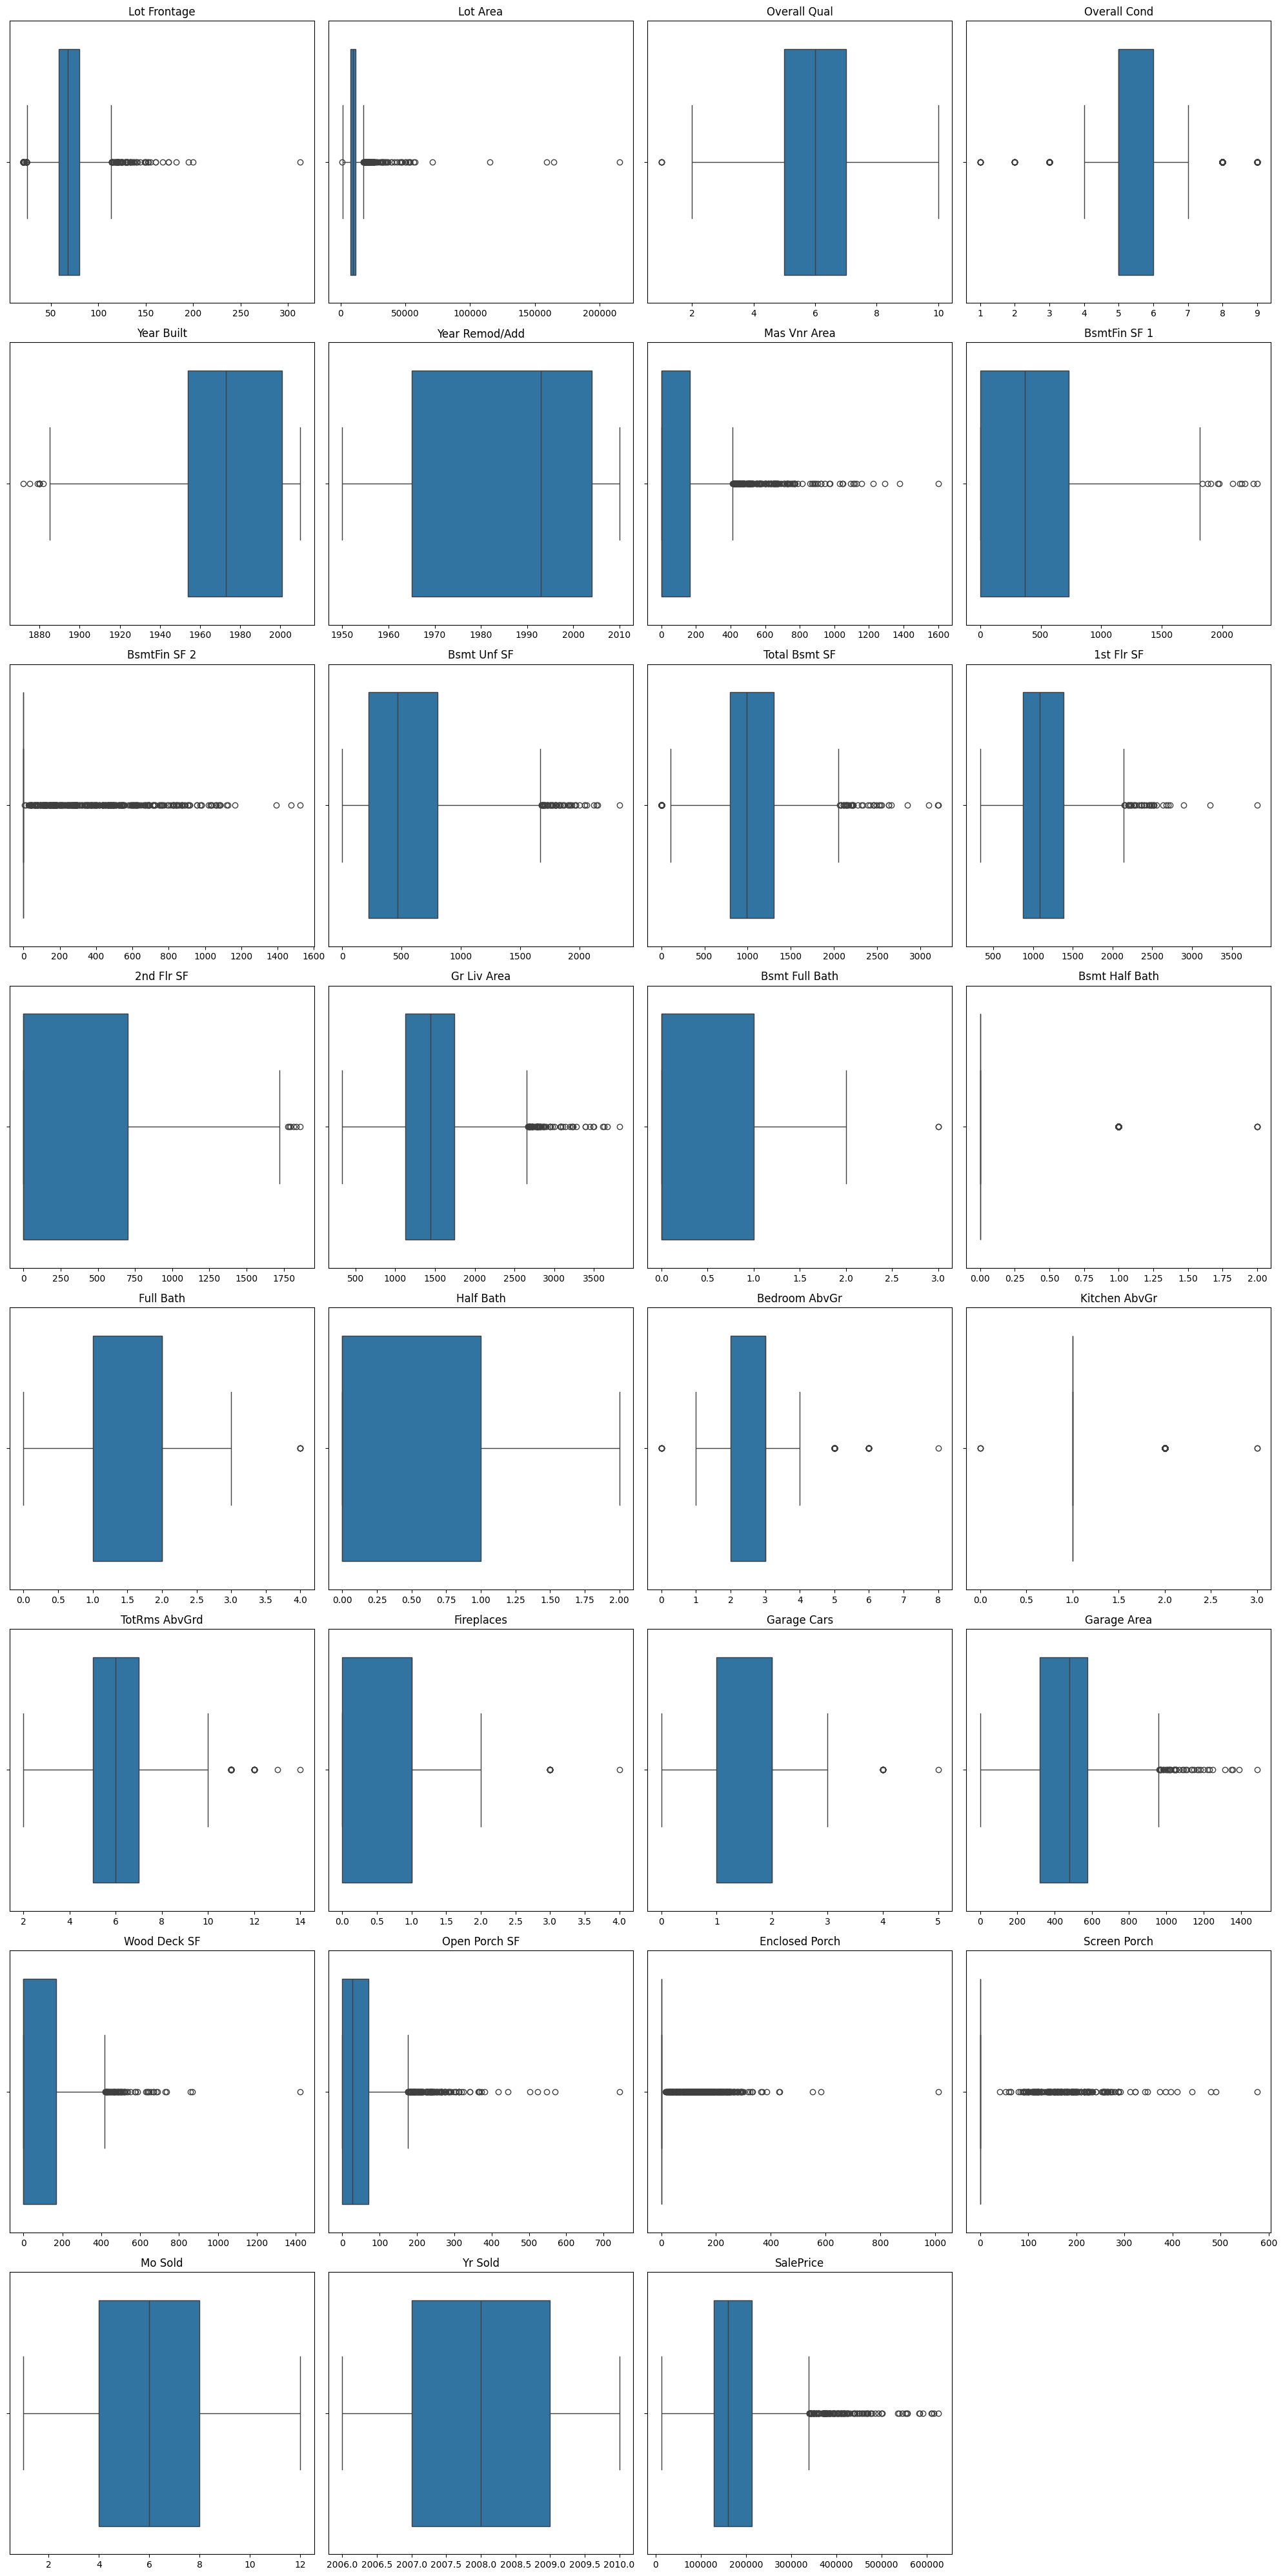

In [21]:
num_cols = len(df_numerics.columns)
num_rows = (num_cols + 3) // 4  # Calculate number of rows needed (4 columns per row)

fig, axes = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(df_numerics.columns):
    sns.boxplot(data=df_numerics, x=col, ax=axes[i])
    axes[i].set_title(col) # Add title to each subplot
    axes[i].set_xlabel('') # Remove x-label from individual plots for compactness

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

The boxplots reveal both many outliers and non-normally distributed variables.


Notably, `SalePrice`, our outcome, has many outliers on the high end of housing prices.
Other variables of concern include:
`Lot Area`, `Gr Liv Area`, `Mas Vnr Area`, `Total Bsmt SF`. These can all be addressed to some degree through transformations.

It is important to address `SalePrice` in particular because highly skewed outcome distributions and extreme observations can disproportionately influence ordinary least squares (OLS) estimates, inflate residual variance, and violate modeling assumptions such as normally distributed and homoscedastic residuals.

Applying a transformation, such as a logarithmic transformation, can reduce skewness, stabilize variance, and improve the interpretability and reliability of inferential results.

---
# Variable transformations

Changing variables mathematically to better fit model assumptions or improve interpretability.

## Common transformations

* Log transformation
    * Useful for skewed variables, multiplicative relationships, diminishing returns.

* Square root transformation
    * Sometimes used for count-like variables.

* Polynomial terms (we will cover this later in the course)
    * To model curves


## Why transformations matter for inference

Regression assumes linearity in parameters and  reasonably well-behaved residuals. Transformations can improve linearity, reduce heteroskedasticity, and stabilize variance by changing the scale of a variable so that relationships between predictors and the outcome better satisfy the assumptions of linear regression. Many real-world variables, especially financial and housing variables such as `SalePrice`, are right-skewed, meaning a small number of observations take extremely large values relative to the rest of the data. In these cases, the relationship between predictors and the response is often multiplicative rather than additive. For example, an additional 500 square feet may increase the value of a small home much more proportionally than it increases the value of a luxury home. A logarithmic transformation compresses large values more than small values, which can make these relationships more approximately linear.

Transformations can also reduce heteroskedasticity, a condition where the variance of the residuals changes across levels of the predictors or fitted values. In housing data, expensive homes often exhibit much larger prediction errors in absolute dollar terms than inexpensive homes. This violates the regression assumption of constant error variance. Applying a transformation such as `log(SalePrice)` often compresses the spread of large values and makes the residual variance more uniform across observations.

Relatedly, transformations can stabilize variance by reducing the influence of extreme observations and bringing the scale of variability into a more consistent range throughout the dataset. This helps prevent a small number of large observations from disproportionately influencing coefficient estimates, standard errors, and hypothesis tests. As a result, transformed models often produce residuals that more closely satisfy the assumptions required for reliable statistical inference.


## Important Note: Interpretation changes


Any kind of transform will change how that variable is subsequently interpreted. For example, in the current dataset a log-transform of `SalePrice` will mean that we must interpret our subsequent results in terms of the log-scale.

---

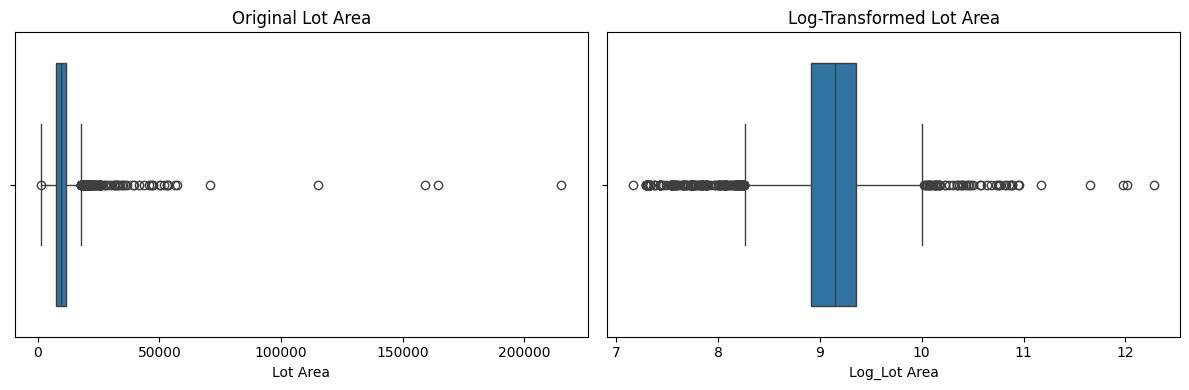

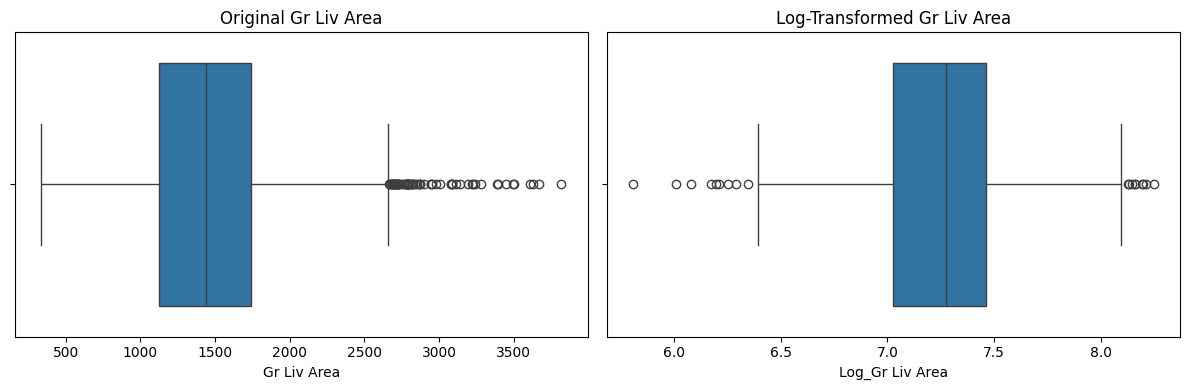

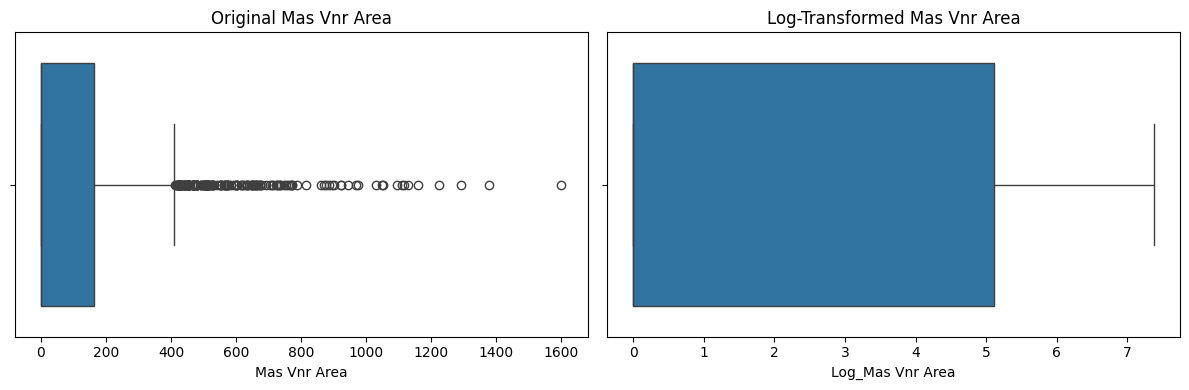

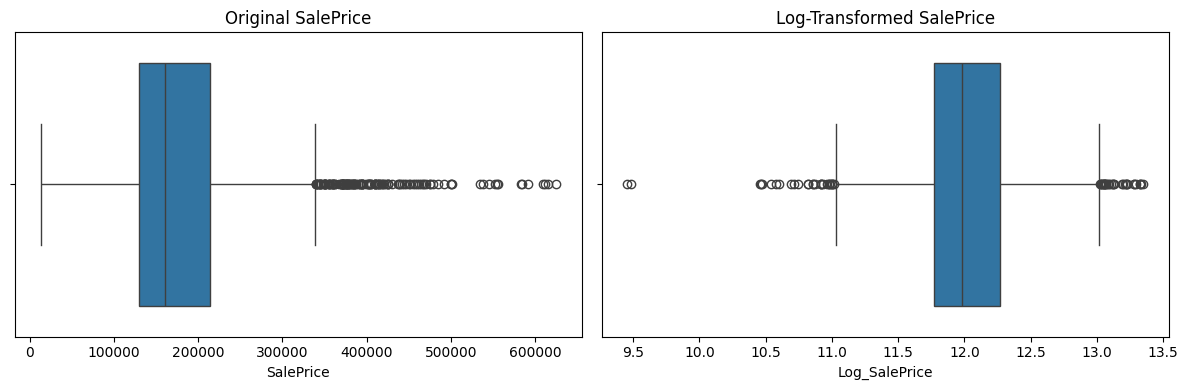

In [22]:
# we are about to do log transforms on columns with missing values
# the code below will handle this situation, but throws warnings
# I've temporarily suppressed these warnings as we know what is happening
import warnings

skewed_cols = ['Lot Area', 'Gr Liv Area', 'Mas Vnr Area', 'SalePrice']

# Temporarily ignore RuntimeWarning for log operations
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    for col in skewed_cols:
        fig, axs = plt.subplots(1, 2, figsize=(12, 4)) # Create a figure with two subplots

        sns.boxplot(data=df, x=col, ax=axs[0])
        axs[0].set_title(f'Original {col}')

        # Apply log1p for columns that can have zero values, log for others
        if col == 'Mas Vnr Area':
            df['Log_'+ col] = np.log1p(df[col]) # this is plus 1 then add the log
        else:
            df['Log_'+ col] = np.log(df[col])

        df = df.drop(columns = col)

        sns.boxplot(data=df, x=('Log_' + col), ax=axs[1])
        axs[1].set_title(f'Log-Transformed {col}')

        plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
        plt.show()

**Why apply log transforms before the split?** The key distinction is between *deterministic* and *statistical* preprocessing steps:

| Type | Examples | Safe before split? |
|---|---|---|
| **Deterministic** — applies a fixed formula, computes nothing from the data | log transform, dtype fix, meaningful-NA fill | ✅ Yes |
| **Statistical** — computes a value *from* the data (mean, median, scale) | median imputation, StandardScaler | ❌ No — must fit on training data only |

A log transform is deterministic: `log(x)` requires knowing nothing about the rest of the dataset. In contrast, median imputation computes the median *from* the training data — if you computed it on the full dataset first, the test set's values would influence what gets imputed into training rows, creating leakage.

This is why the train/test split comes *after* log transforms but *before* imputation, feature engineering, and encoding.






## Cleaning Specifically with MLR in Mind
Preparing data specifically for multiple linear regression (MLR)  requires strict adherence to the algorithm’s statistical assumptions.
* Because MLR relies on ordinary least squares (OLS) optimization, it is highly sensitive to missing values and extreme outliers, both of which can disproportionately pull the line of best fit and must be carefully imputed, capped, or removed.
* Since the MLR equation requires strictly numeric inputs, categorical data must be converted into binary flags using one-hot encoding, with the critical step of dropping one baseline category to avoid the "dummy variable trap" (perfect multicollinearity).
* Mitigating multicollinearity is a primary focus of MLR
cleaning. We routinely use Variance Inflation Factor (VIF) scores to
identify and remove highly correlated overlapping predictors that would
otherwise cause the model's coefficient estimates to become wildly unstable and
meaningless.
* Applying mathematical transformations (such as logarithmic
scaling) to highly skewed variables helps satisfy the strict assumptions of
linearity and homoscedasticity, ensuring the final model is not just
mathematically functional, but statistically valid and interpretable.


# Part 2: The Train/Test Split
Before computing any **statistics from the data** — medians for imputation, scale parameters, learned encodings — we split into training and test sets. Everything from this point forward must be fit on the training set only, then applied to both.

The log transforms and structural fixes in Part 1 were applied before this split because they are deterministic (they use no statistics from the data). All remaining steps — imputation, feature engineering, encoding — will be fit on training data only and then applied identically to both sets.

In [23]:
# Train/Test Split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Training set: {df_train.shape}")
print(f"Test set: {df_test.shape}")

Training set: (2340, 66)
Test set: (585, 66)


## Part 3: Handling Missing and Extreme Values (Train-Set Only)
Now we handle true missing values.

In [ ]:
# Statistical Imputation (in this case median replacement)
from sklearn.impute import SimpleImputer

# Identify numeric columns for imputation
numeric_cols = df_train.select_dtypes(include=np.number).columns

# Use SimpleImputer to learn medians from train and apply to both train and test.
# This prevents crashes if a missing value appears in test data but not train data!
imputer = SimpleImputer(strategy='median')

# Fit on training data ONLY, then transform both
df_train[numeric_cols] = imputer.fit_transform(df_train[numeric_cols])  # this fits and transforms
df_test[numeric_cols] = imputer.transform(df_test[numeric_cols])         # this only transforms

## Part 4: Feature Engineering

We consolidate the three correlated floor-area columns into a single `Total_Square_Footage` feature. This reduces collinearity among the component variables while preserving the overall size signal.

> **Note:** `Log_Gr Liv Area` (above-grade living area = 1st floor + 2nd floor) is still in the dataset, and `Total_Square_Footage` adds basement area on top of the same two floors. This means the two features substantially overlap. We will detect and address this multicollinearity using VIF diagnostics in Part 2.

In [25]:
# Create Synergistic Features
df_train['Total_Square_Footage'] = df_train['1st Flr SF'] + df_train['2nd Flr SF'] + df_train['Total Bsmt SF']
df_test['Total_Square_Footage'] = df_test['1st Flr SF'] + df_test['2nd Flr SF'] + df_test['Total Bsmt SF']

# Drop the components to avoid multicollinearity
df_train = df_train.drop(['1st Flr SF', '2nd Flr SF', 'Total Bsmt SF'], axis=1)
df_test = df_test.drop(['1st Flr SF', '2nd Flr SF', 'Total Bsmt SF'], axis=1)

## Part 5: Encoding Categoricals for the Algorithm
Because MLR requires strict numeric inputs, we must translate text to math. We use Ordinal Encoding for ranked variables, and One-Hot Encoding (Nominal) for unranked variables.

In [26]:
# Ordinal Encoding
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0} # TA is typical/average
ordinal_cols = ['Exter Qual', 'Kitchen Qual', 'Heating QC', 'Bsmt Qual', 'Fireplace Qu']

for col in ordinal_cols:
    df_train[col] = df_train[col].map(quality_map).fillna(3)
    df_test[col] = df_test[col].map(quality_map).fillna(3)

# Garage Finish has a different mapping
garage_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
df_train['Garage Finish'] = df_train['Garage Finish'].map(garage_map).fillna(0)
df_test['Garage Finish'] = df_test['Garage Finish'].map(garage_map).fillna(0)

In [30]:
# Nominal Encoding (One-Hot)
from sklearn.preprocessing import OneHotEncoder

# Select all remaining categorical columns to prevent the "Categorical Massacre"
# This retains valuable info like Sale Condition
nominal_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Encoding nominal columns: {nominal_cols}")

# Initialize OneHotEncoder.
# drop='first' avoids the dummy variable trap.
# handle_unknown='ignore' gracefully handles unseen categories in the test set without crashing.
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Fit on train and transform both
encoded_train = encoder.fit_transform(df_train[nominal_cols])
encoded_test = encoder.transform(df_test[nominal_cols])

# Get new feature names
encoded_cols = encoder.get_feature_names_out(nominal_cols)

# Create dataframes with encoded columns
df_encoded_train = pd.DataFrame(encoded_train, columns=encoded_cols, index=df_train.index)
df_encoded_test = pd.DataFrame(encoded_test, columns=encoded_cols, index=df_test.index)

# Drop original nominal columns and join encoded ones
df_train = df_train.drop(nominal_cols, axis=1).join(df_encoded_train)
df_test = df_test.drop(nominal_cols, axis=1).join(df_encoded_test)


Encoding nominal columns: []


Note on the warning: The warning is informational and extremely common in train/test workflows with categorical variables. What it means is that
the encoder learned categories from the training set, the test set contains categories never observed during fitting, those unseen categories are encoded as all zeros for that feature.

This is usually preferable to crashing, or leaking test information into training. We can leave it as is.

## Part 6: Target Variable Housekeeping
We've transformed SalePrice to Log_SalePrice, but it's still sitting inside our feature sets. If we passed this directly into a model, the algorithm would use Log_SalePrice to predict Log_SalePrice. We must separate our features (X) and target (y).

In [32]:
# 12. Separate Features (X) and Target (y)
X_train = df_train.drop('Log_SalePrice', axis=1)
y_train = df_train['Log_SalePrice']

X_test = df_test.drop('Log_SalePrice', axis=1)
y_test = df_test['Log_SalePrice']

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (2340, 224), y_train shape: (2340,)
X_test shape: (585, 224), y_test shape: (585,)


## Summary

By following this order — **Structure → Deterministic Transforms → Split → Impute → Feature Engineer → Encode → Separate Target** — we ensured that our model remains statistically pure (no data leakage), retains its valuable signals (proper encoding), and respects the strict mathematical requirements of Multiple Linear Regression.

The key rule: steps that compute nothing from the data (log transforms, meaningful-NA fills, dtype fixes) are safe to apply before the split. Steps that compute statistics from the data (median imputation, scaling, learned encodings) must be fit on the training set only and then applied to both sets.

### Where This Work Goes Next

All of the cleaning steps we walked through here have been packaged into a reusable module called `ames_cleaning.py`. In Part 2, we will load that module and call `load_and_clean_ames()`, which applies every decision we just made.

One thing to keep in mind: after one-hot encoding, this dataset expands to roughly 225 features. Part 2 immediately shortlists down to about 40 candidates using a Pearson correlation filter before running forward/backward feature selection. This filter is fast but imperfect — it is biased against one-hot-encoded categorical columns, which tend to show lower individual correlation with the target even when they carry real predictive signal. Watch for how Part 2 surfaces and addresses that tradeoff.